In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
import json
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


from sklearn.decomposition import PCA
from scipy.stats import zscore

In [2]:
# suppress display of warnings
warnings.filterwarnings('ignore')

# display all dataframe columns
pd.options.display.max_columns = None

# to set the limit to 3 decimals
pd.options.display.float_format = '{:.7f}'.format

# display all dataframe rows
pd.options.display.max_rows = None

#### Question:1 - Import and warehouse data

###### Import all the given datasets and explore shape and size.

In [14]:
df1=pd.read_csv('C:\AIML\Assessment\R4-UnSupervised\External\Car+name.csv')

In [4]:
df1.shape

(398, 1)

In [15]:
df2=pd.read_json('C:\AIML\Assessment\R4-UnSupervised\External\Car-Attributes.json')

In [16]:
df2.shape

(398, 8)

In [8]:
df2.head(10)

,mpg,cyl,disp,hp,wt,acc,yr,origin
0,18.0000000,8,307.0000000,130,3504,12.0000000,70,1
1,15.0000000,8,350.0000000,165,3693,11.5000000,70,1
2,18.0000000,8,318.0000000,150,3436,11.0000000,70,1
3,16.0000000,8,304.0000000,150,3433,12.0000000,70,1
4,17.0000000,8,302.0000000,140,3449,10.5000000,70,1
5,15.0000000,8,429.0000000,198,4341,10.0000000,70,1
6,14.0000000,8,454.0000000,220,4354,9.0000000,70,1
7,14.0000000,8,440.0000000,215,4312,8.5000000,70,1
8,14.0000000,8,455.0000000,225,4425,10.0000000,70,1
9,15.0000000,8,390.0000000,190,3850,8.5000000,70,1


###### Merge all datasets onto one and explore final shape and size.

In [17]:
df_final_AM=pd.concat([df1,df2], axis=1)

In [18]:
df_final_AM.shape

(398, 9)

In [19]:
df_final_AM.head(10)

,car_name,mpg,cyl,disp,hp,wt,acc,yr,origin
0,chevrolet chevelle malibu,18.0000000,8,307.0000000,130,3504,12.0000000,70,1
1,buick skylark 320,15.0000000,8,350.0000000,165,3693,11.5000000,70,1
2,plymouth satellite,18.0000000,8,318.0000000,150,3436,11.0000000,70,1
3,amc rebel sst,16.0000000,8,304.0000000,150,3433,12.0000000,70,1
4,ford torino,17.0000000,8,302.0000000,140,3449,10.5000000,70,1
5,ford galaxie 500,15.0000000,8,429.0000000,198,4341,10.0000000,70,1
6,chevrolet impala,14.0000000,8,454.0000000,220,4354,9.0000000,70,1
7,plymouth fury iii,14.0000000,8,440.0000000,215,4312,8.5000000,70,1
8,pontiac catalina,14.0000000,8,455.0000000,225,4425,10.0000000,70,1
9,amc ambassador dpl,15.0000000,8,390.0000000,190,3850,8.5000000,70,1


In [12]:
df_final_AM.groupby(['car_name']).count()

,mpg,cyl,disp,hp,wt,acc,yr,origin
car_name,,,,,,,,
amc ambassador brougham,1,1,1,1,1,1,1,1
amc ambassador dpl,1,1,1,1,1,1,1,1
amc ambassador sst,1,1,1,1,1,1,1,1
amc concord,2,2,2,2,2,2,2,2
amc concord d/l,1,1,1,1,1,1,1,1
amc concord dl,1,1,1,1,1,1,1,1
amc concord dl 6,1,1,1,1,1,1,1,1
amc gremlin,4,4,4,4,4,4,4,4
amc hornet,4,4,4,4,4,4,4,4


###### Export the final dataset and store it on local machine in .csv, .xlsx and .json format for future use.

In [22]:
df_final_AM.to_csv("ConcatedAutoMob.csv",index=False)

In [23]:
df_final_AM.to_excel("ConcatedAutoMob.xlsx",index=False)

In [24]:
df_final_AM.to_json("ConcatedAutoMob.json")

###### Import the data from above steps into python.

In [25]:
# load the resultant csv file 
df_final = pd.read_csv("ConcatedAutoMob.csv") 

In [26]:
df_final.shape

(398, 9)

In [27]:
df_final.columns

Index(['car_name', 'mpg', 'cyl', 'disp', 'hp', 'wt', 'acc', 'yr', 'origin'], dtype='object')

#### Question: 2 - Data cleansing:

###### Q2.1 Missing/incorrect value treatment

In [28]:
df_final.dtypes

car_name     object
mpg         float64
cyl           int64
disp        float64
hp           object
wt            int64
acc         float64
yr            int64
origin        int64
dtype: object

In [29]:
df_final.isnull().sum() #There are no null values in any of these columns.

car_name    0
mpg         0
cyl         0
disp        0
hp          0
wt          0
acc         0
yr          0
origin      0
dtype: int64

In [30]:
#Let's change the "?" with 'Nan' first and then update missing values with median.
df_final['hp']=df_final['hp'].replace('?', np.nan)
df_final['hp']=df_final['hp'].fillna(df_final['hp'].median())

In [31]:
df_final['hp']=df_final['hp'].astype('float64')

In [32]:
df_final.dtypes

car_name     object
mpg         float64
cyl           int64
disp        float64
hp          float64
wt            int64
acc         float64
yr            int64
origin        int64
dtype: object

In [33]:
df_final.columns

Index(['car_name', 'mpg', 'cyl', 'disp', 'hp', 'wt', 'acc', 'yr', 'origin'], dtype='object')

In [34]:
df_final.nunique()

car_name    305
mpg         129
cyl           5
disp         82
hp           94
wt          351
acc          95
yr           13
origin        3
dtype: int64

In [35]:
df_final.duplicated().value_counts() #There are no duplicates in the dataset.

False    398
dtype: int64

###### Drop attribute/s if required using relevant functional knowledge

In [36]:
#Drop the car name as it is useless to build a model.
df_final = df_final.drop('car_name', axis=1)

In [37]:
df_final.columns

Index(['mpg', 'cyl', 'disp', 'hp', 'wt', 'acc', 'yr', 'origin'], dtype='object')

###### Perform another kind of corrections/treatment on the data.

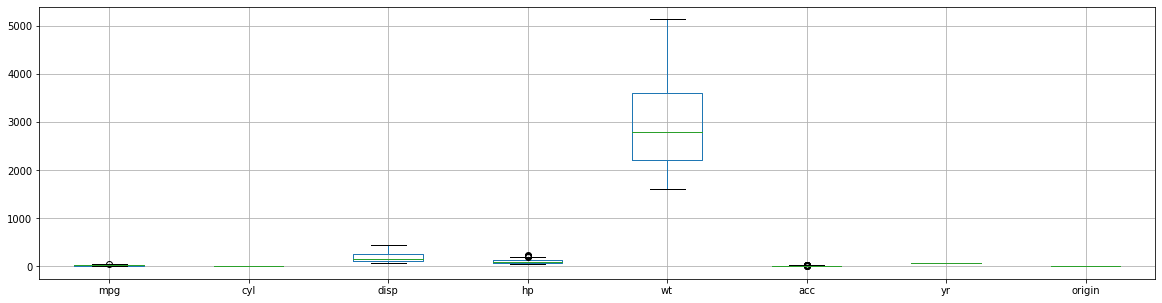

In [38]:
df_final.boxplot(figsize=(20,5))

In [39]:
#Treat Outliers
def out_iqr(df_final , column):
    global lower,upper
    q25, q75 = np.quantile(df_final[column], 0.25), np.quantile(df_final[column], 0.75)
    # calculate the IQR
    iqr = q75 - q25
    # calculate the outlier cutoff
    cut_off = iqr * 1.5
    # calculate the lower and upper bound value
    lower, upper = q25 - cut_off, q75 + cut_off
    print('The IQR is',iqr)
    print('The lower bound value is', lower)
    print('The upper bound value is', upper)
    # Calculate the number of records below and above lower and above bound value respectively
    df1 = df_final[df_final[column] > upper]
    df2 = df_final[df_final[column] < lower]
    return print('Total number of outliers are', df1.shape[0]+ df2.shape[0])

In [40]:
out_iqr(df_final,'hp')

The IQR is 49.0
The lower bound value is 2.5
The upper bound value is 198.5
Total number of outliers are 11


In [41]:
out_iqr(df_final,'acc')

The IQR is 3.349999999999996
The lower bound value is 8.800000000000008
The upper bound value is 22.199999999999992
Total number of outliers are 9


In [42]:
out_iqr(df_final,'mpg')

The IQR is 11.5
The lower bound value is 0.25
The upper bound value is 46.25
Total number of outliers are 1


In [43]:
df_final.loc[df_final['hp'] > 198, 'hp'] = 198.5

In [44]:
df_final.loc[df_final['mpg'] > 46.25, 'mpg'] = 46.25

In [45]:
df_final.loc[df_final['acc'] > 17, 'acc'] = 21

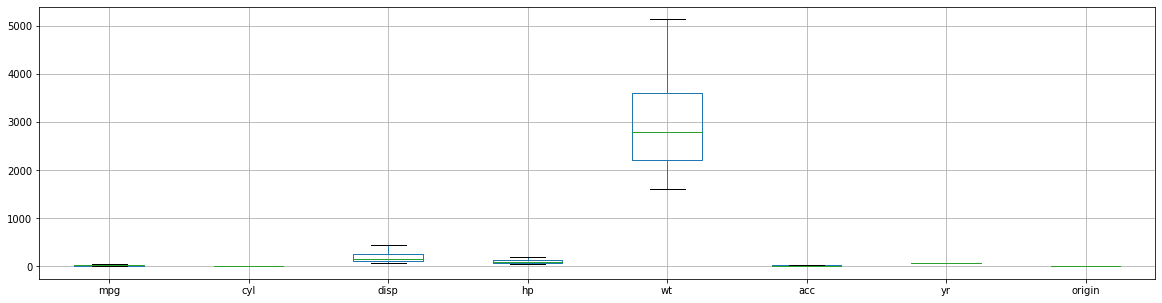

In [46]:
df_final.boxplot(figsize=(20,5))

#### Question 3:  Data analysis & visualisation:

###### Perform detailed statistical analysis on the data.

In [47]:
df_final.describe().T #Lets see a descriptive summary to do further analysis.

,count,mean,std,min,25%,50%,75%,max
mpg,398.0000000,23.5136935,7.8133996,9.0000000,17.5000000,23.0000000,29.0000000,46.2500000
cyl,398.0000000,5.4547739,1.7010042,3.0000000,4.0000000,4.0000000,8.0000000,8.0000000
disp,398.0000000,193.4258794,104.2698382,68.0000000,104.2500000,148.5000000,262.0000000,455.0000000
hp,398.0000000,103.7902010,36.7704682,46.0000000,76.0000000,93.5000000,125.0000000,198.5000000
wt,398.0000000,2970.4246231,846.8417742,1613.0000000,2223.7500000,2803.5000000,3608.0000000,5140.0000000
acc,398.0000000,16.0429648,3.3122531,8.0000000,13.8250000,15.5000000,21.0000000,21.0000000
yr,398.0000000,76.0100503,3.6976266,70.0000000,73.0000000,76.0000000,79.0000000,82.0000000
origin,398.0000000,1.5728643,0.8020549,1.0000000,1.0000000,1.0000000,2.0000000,3.0000000


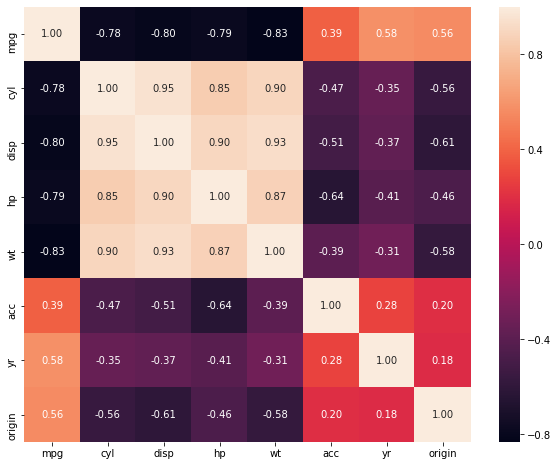

In [48]:
fig,ax = plt.subplots(figsize=(10, 8))   
sns.heatmap(df_final.corr(), ax=ax, annot=True, fmt= '.2f') # the color intensity is based on
bottom, top = ax.get_ylim()
ax.set_ylim(bottom + 0.5, top - 0.5)
plt.show()

From above correlation - the observation is that target variable "mpg" is less correlated with independent variables.
Whereas there is a high correlation between cycl, disp, hp and wt independent variables.

In [49]:
df_final['origin'].value_counts()

1    249
3     79
2     70
Name: origin, dtype: int64

In [50]:
df_final.groupby(df_final['mpg']).median()

,cyl,disp,hp,wt,acc,yr,origin
mpg,,,,,,,
9.0000000,8.0000000,304.0000000,193.0000000,4732.0000000,21.0000000,70.0000000,1.0000000
10.0000000,8.0000000,333.5000000,198.5000000,4495.5000000,14.5000000,70.0000000,1.0000000
11.0000000,8.0000000,375.0000000,189.2500000,4507.5000000,12.2500000,72.5000000,1.0000000
12.0000000,8.0000000,391.5000000,180.0000000,4928.5000000,12.0000000,73.0000000,1.0000000
13.0000000,8.0000000,350.0000000,152.5000000,4284.0000000,13.0000000,73.0000000,1.0000000
14.0000000,8.0000000,350.0000000,153.0000000,4237.0000000,13.0000000,72.0000000,1.0000000
14.5000000,8.0000000,351.0000000,152.0000000,4215.0000000,12.8000000,76.0000000,1.0000000
15.0000000,8.0000000,318.0000000,150.0000000,3769.0000000,12.7500000,73.0000000,1.0000000
15.5000000,8.0000000,350.0000000,145.0000000,4140.0000000,13.7000000,77.0000000,1.0000000


In [51]:
df_final.var()

mpg          61.0492138
cyl           2.8934154
disp      10872.1991522
hp         1352.0673345
wt       717140.9905257
acc          10.9710209
yr           13.6724428
origin        0.6432920
dtype: float64

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x000002205D0D5708>,
      dtype=object)

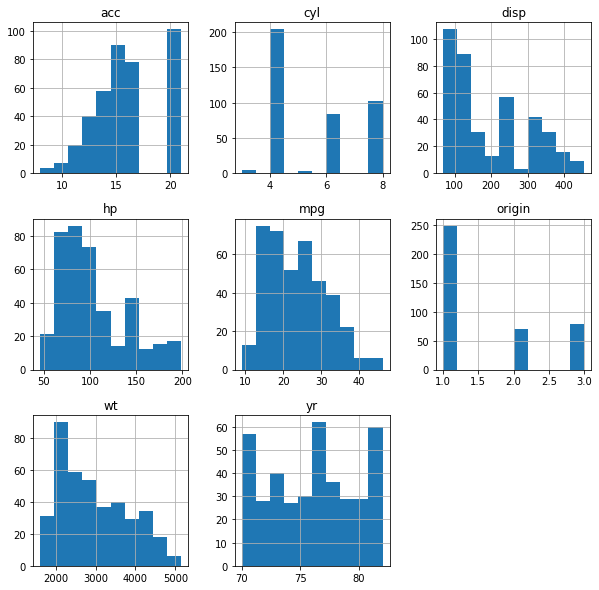

In [53]:
df_final.hist(figsize=(10,10))

#### Perform a detailed univariate, bivariate and multivariate analysis with appropriate detailed comments after each analysis.

#### Univariate Analysis: Lets see how the highly correlated features are distributed.

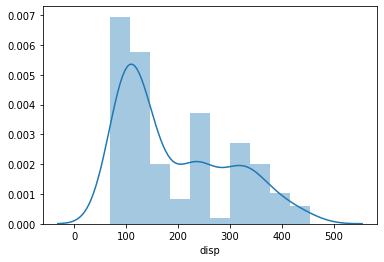

In [54]:
sns.distplot(df_final['disp']) # The disp data is toward right skewed.

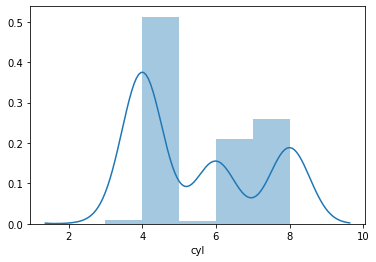

In [55]:
sns.distplot(df_final['cyl'])  # The cycle feature has multiple peaks and correlated with other features.

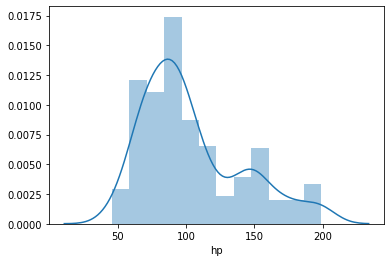

In [56]:
sns.distplot(df_final['hp']) # The hp feature is right skewed and has high correlation with target variable.

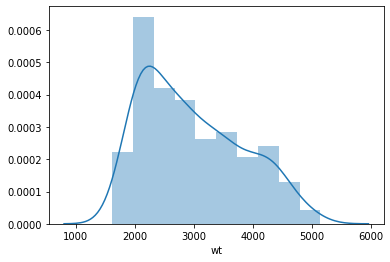

In [57]:
sns.distplot(df_final['wt']) # This weight feature is right skewed and correlated highly with target var - mpg.

#### Bivariate Analysis: Lets see distribution between target variable and independent varaible.

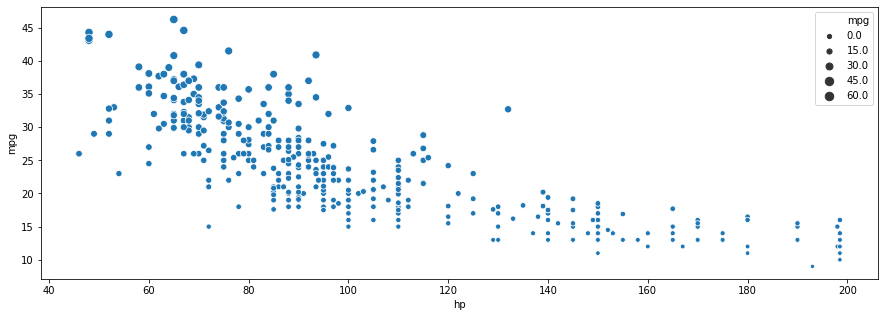

In [58]:
# Scatter plot

figure = plt.figure(figsize=(15,5))
ax = sns.scatterplot(x=df_final['hp'],y='mpg', data=df_final, size = "mpg")

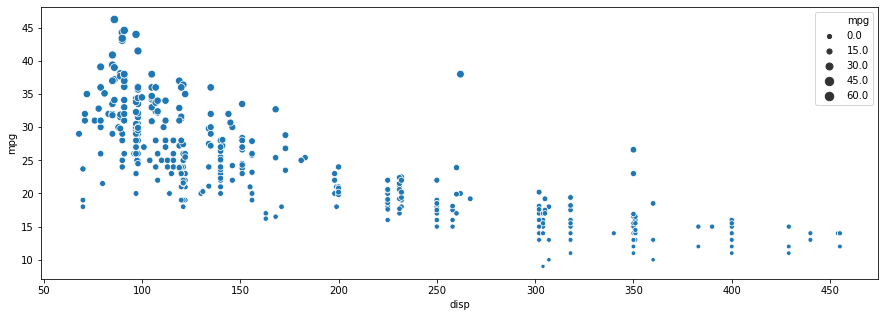

In [59]:
figure = plt.figure(figsize=(15,5))
ax = sns.scatterplot(x=df_final['disp'],y='mpg', data=df_final, size = "mpg")

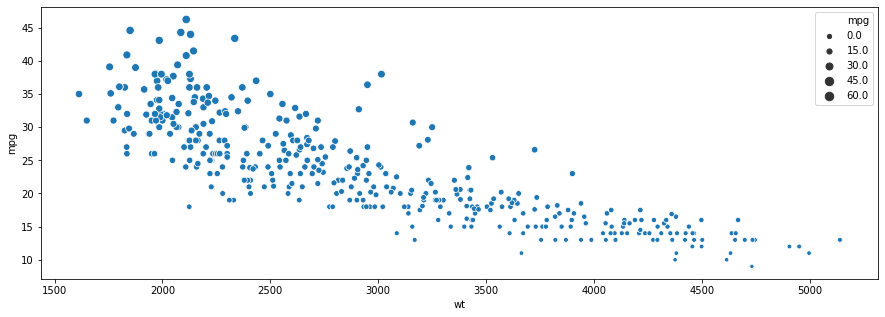

In [60]:
figure = plt.figure(figsize=(15,5))
ax = sns.scatterplot(x=df_final['wt'],y='mpg', data=df_final, size = "mpg")

From above plot, observtaion is that the mpg decreases when wt of a car increases.

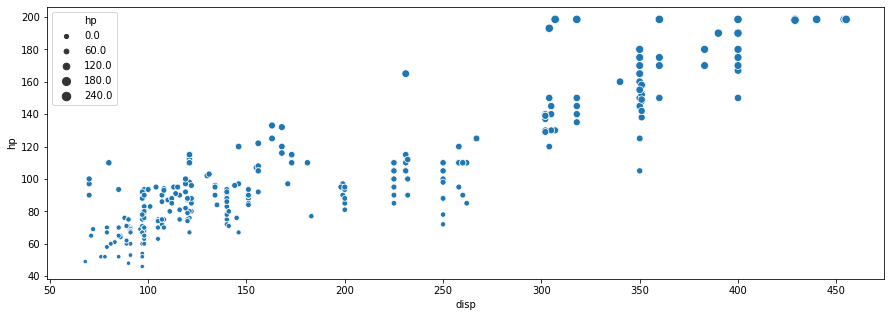

In [61]:
figure = plt.figure(figsize=(15,5))
ax = sns.scatterplot(x=df_final['disp'],y='hp', data=df_final, size = "hp")

Between 2 independent variables - hp and disp, it is observed that 'hp' gradually when 'disp' is increased. These 2 features are highly correlated.

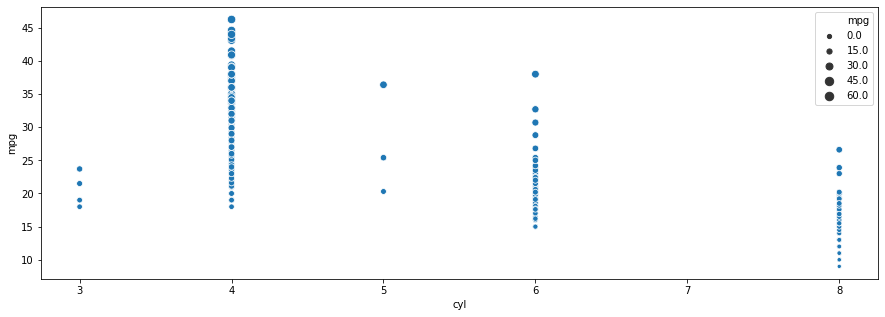

In [62]:
figure = plt.figure(figsize=(15,5))
ax = sns.scatterplot(x=df_final['cyl'],y='mpg', data=df_final, size = "mpg")

The "mpg" target variable decreases when the no.of cyl is increased. This is similar to disp Vs mpg feature observation.

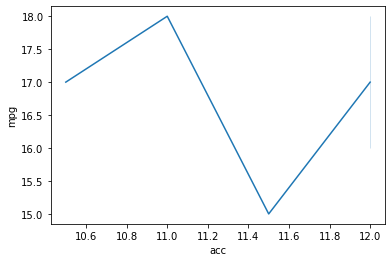

In [63]:
#Here we plotting a line plot.
sns.lineplot(x='acc',y='mpg', data=df_final.head() )

#### Multivariate Analysis - in a highlevel, lets visualize the correlation between each feature using pairplot.

###### Hint: Use your best analytical approach. Even you can mix match columns to create new columns which can be used for better analysis. Create your own features if required. Be highly experimental and analytical here to find hidden patterns.

In [65]:
df_final = df_final.iloc[:, 0:8]
df_final['dispercyl'] = df_final['disp'] / df_final['cyl']

In [66]:
df_final.shape

(398, 9)

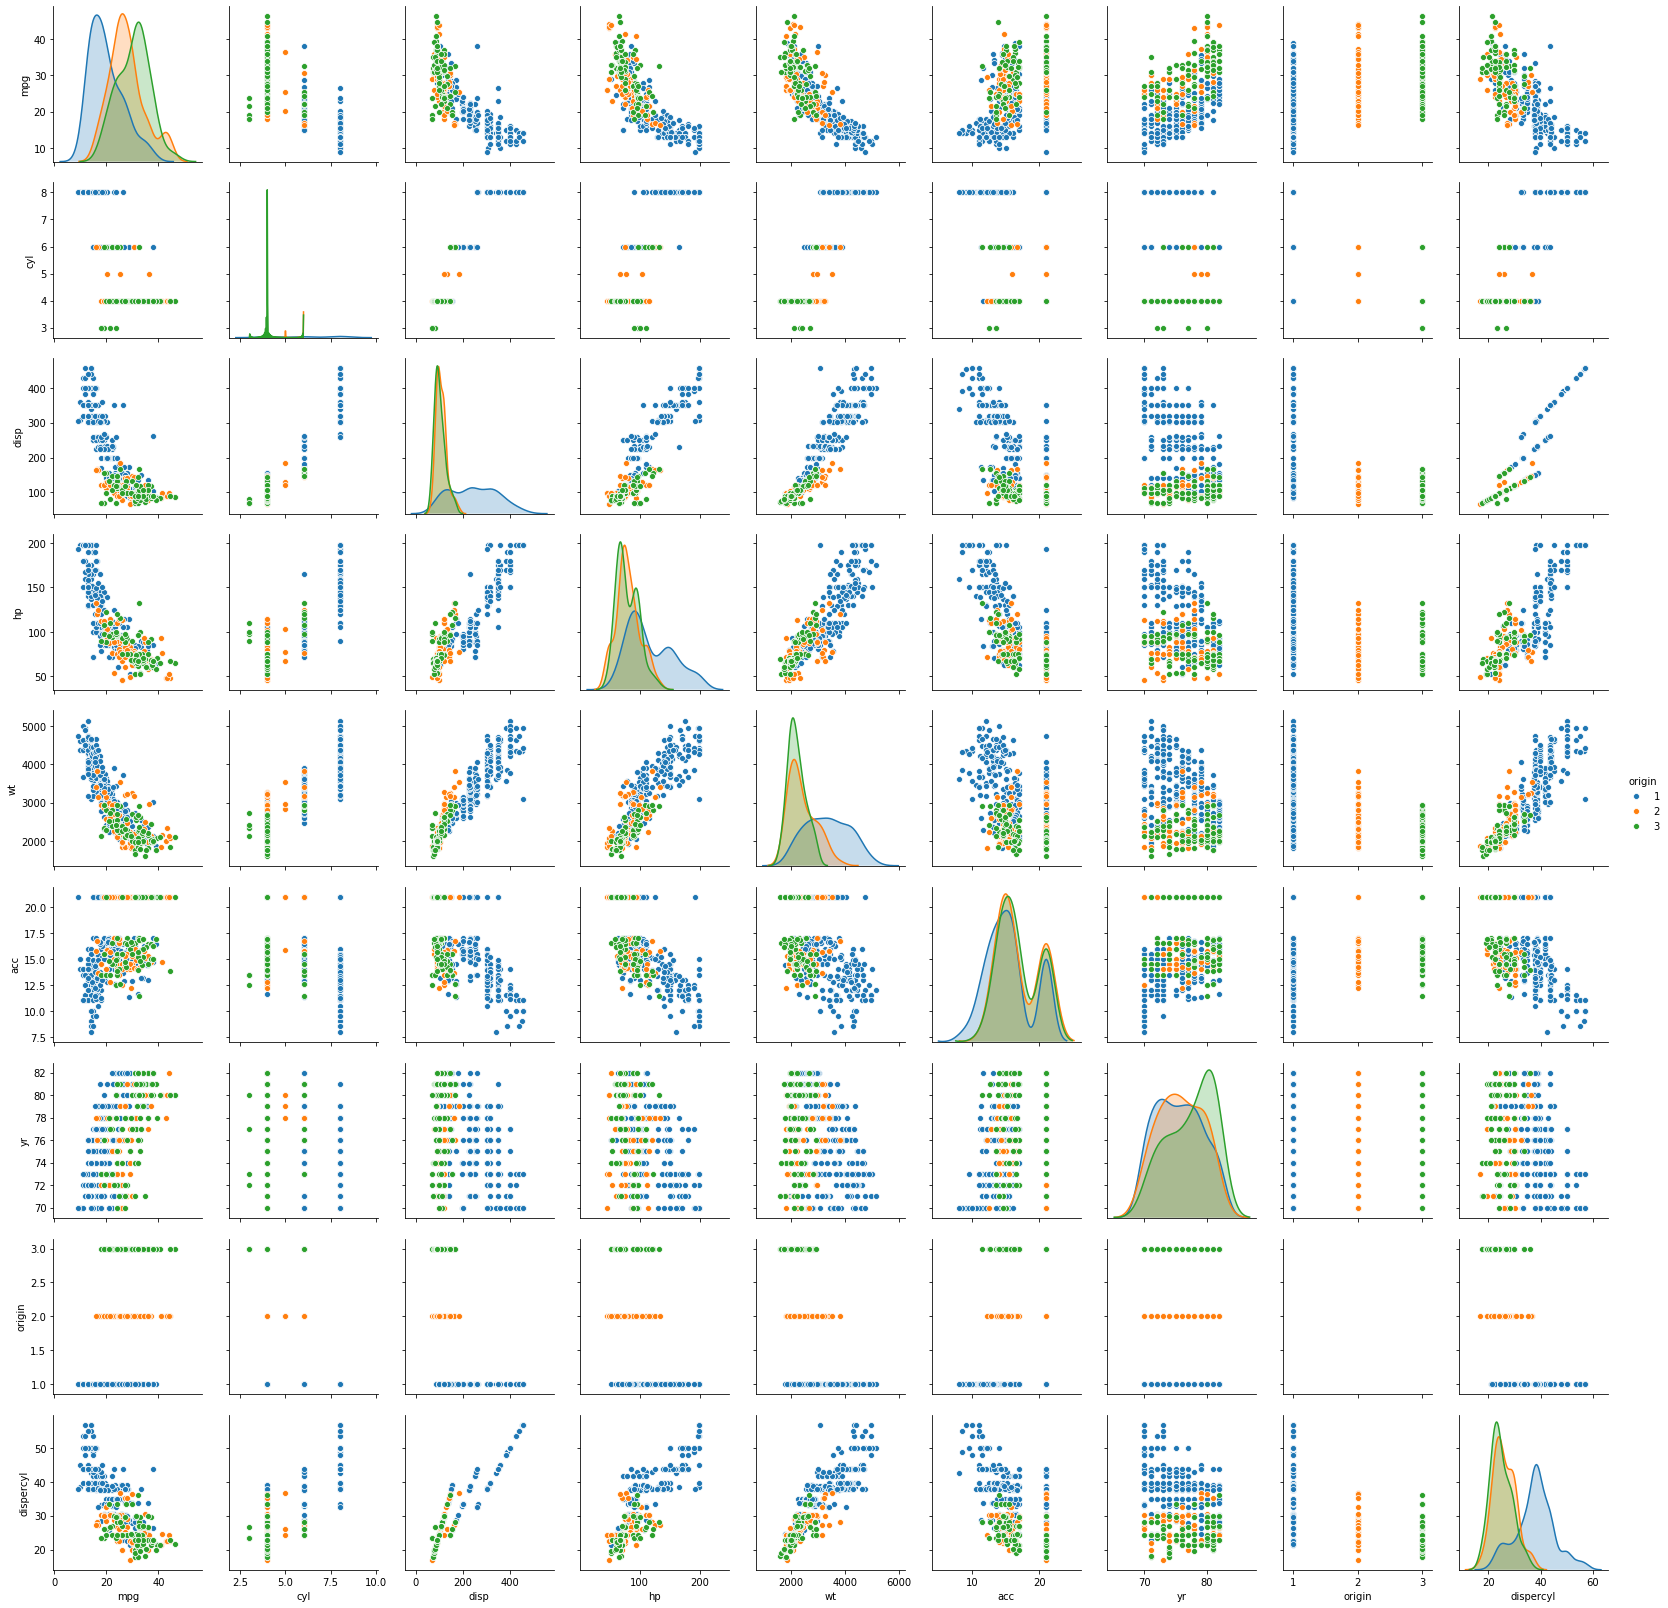

In [67]:
sns.pairplot(df_final,diag_kind ='kde', hue='origin')

From the pairplot, following are observation:
1. The disp and cyl features has similar observations - when these feature values are increased, the target var 'mpg' is decreased. so we can combine these 2 features to have a new feature "disperCyl" which will give better understanding on data.
2. The independent variable - disp, cyl, hp, wt are highly correlated each other and against target variable.
3. The independent variables - acc, yr, origin has very less / negative correlation with the target variable.

###### Question #4: Machine learning:

#### Use K Means and Hierarchical clustering to find out the optimal number of clusters in the data.

K Means clustering - approach 1

In [68]:
from sklearn.cluster import KMeans
from scipy.spatial import distance
from scipy.stats import zscore

In [69]:
#drop the target variable and useless variablebefore applying K Means
#apply zscore to standardize the data.
df_final = df_final.loc[:, 'mpg':'origin']
df_final_z = df_final.apply(zscore)

#df_final_z_cluster.pop('origin')      # Remove "origin" and "yr" columns
#df_final_z_cluster.pop('yr')
df_final_z.drop(['yr', 'origin'],  axis=1, inplace=True)
df_final_z.drop(['mpg'], axis=1, inplace=True)

In [70]:
df_final_z

,cyl,disp,hp,wt,acc
0,1.4981913,1.0906037,0.7136920,0.6308699,-1.2221450
1,1.4981913,1.5035143,1.6667408,0.8543330,-1.3732896
2,1.4981913,1.1962320,1.2582913,0.5504705,-1.5244343
3,1.4981913,1.0617960,1.2582913,0.5469234,-1.2221450
4,1.4981913,1.0425908,0.9859916,0.5658409,-1.6755789
5,1.4981913,2.2621175,2.5653298,1.6204922,-1.8267235
6,1.4981913,2.5021818,2.5789447,1.6358626,-2.1290128
7,1.4981913,2.3677458,2.5789447,1.5862042,-2.2801575
8,1.4981913,2.5117844,2.5789447,1.7198091,-1.8267235
9,1.4981913,1.8876172,2.3474900,1.0399610,-2.2801575


In [71]:
cluster_range = range( 2, 6)   # expect 3 to four clusters from the pair panel visual inspection hence restricting from 2 to 6

# Let us check optimal number of clusters-
cluster_errors = []
for num_clusters in cluster_range:
  clusters = KMeans( num_clusters, n_init = 5, random_state = 5)
  clusters.fit(df_final_z)
    #predictions
  labels = clusters.labels_                                # capture the cluster lables
  centroids = clusters.cluster_centers_                    # capture the centroids
    
  cluster_errors.append( clusters.inertia_ )               # capture the intertia
clusters_df = pd.DataFrame( { "num_clusters":cluster_range, "cluster_errors": cluster_errors } )
clusters_df[0:15]

,num_clusters,cluster_errors
0,2,722.6369106
1,3,471.4143113
2,4,321.3296250
3,5,255.6846711


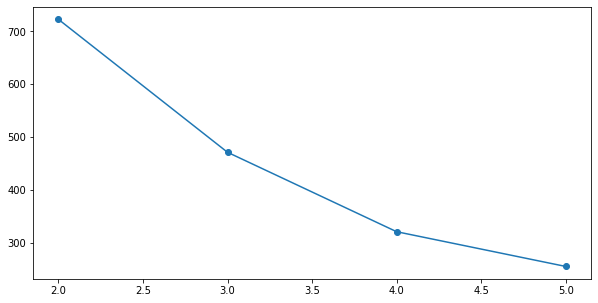

In [72]:
# Elbow plot

plt.figure(figsize=(10,5))
plt.plot( clusters_df.num_clusters, clusters_df.cluster_errors, marker = "o" )

From elbow plot, it is clear that there are 3 or 4 good clusters in the data. Lets use 3 clusters to build a model.

In [73]:
#Build and build a model - by clustering.
cluster = KMeans( n_clusters = 3, random_state = 12 )

# Fitting the input data
cluster.fit(df_final_z)

# Creating a mirror copy for later re-use instead of building repeatedly
df_final_z_copy = df_final_z.copy(deep = True)  


# Getting the cluster labels
labels = cluster.predict(df_final_z)

# Centroid values
centroids = cluster.cluster_centers_

# Comparing with scikit-learn centroids

print("Centroid values for 3 clusters")

print(centroids) # From sci-kit learn

Centroid values for 3 clusters
[[ 0.39287876  0.27843948 -0.07885136  0.30332106  0.34640057]
 [-0.86192655 -0.80839642 -0.67211887 -0.77447597  0.32442462]
 [ 1.48617844  1.47656831  1.51266923  1.38103122 -1.01331859]]


For n_clusters = 2 The average silhouette_score is : 0.5755301845778484
For n_clusters = 3 The average silhouette_score is : 0.46532482357445115
For n_clusters = 4 The average silhouette_score is : 0.5048324011755003
For n_clusters = 5 The average silhouette_score is : 0.5181618911737355
For n_clusters = 6 The average silhouette_score is : 0.48517361300561296


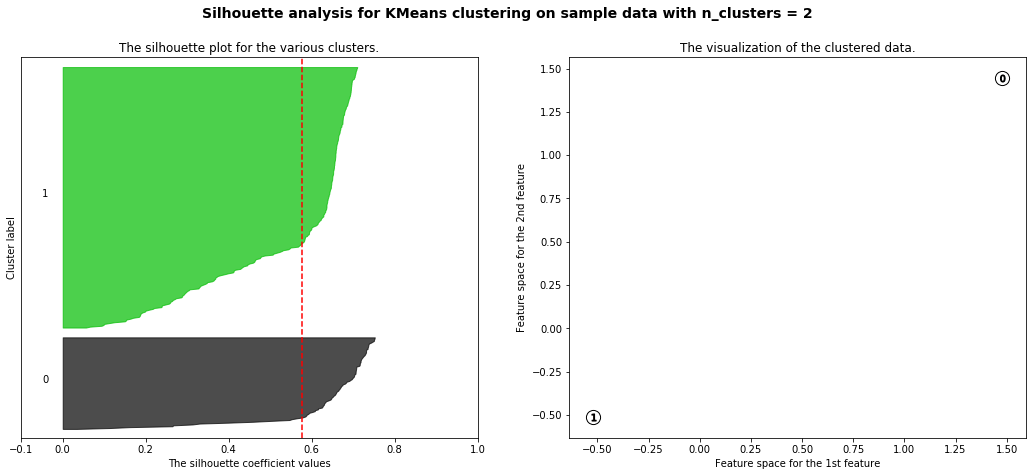

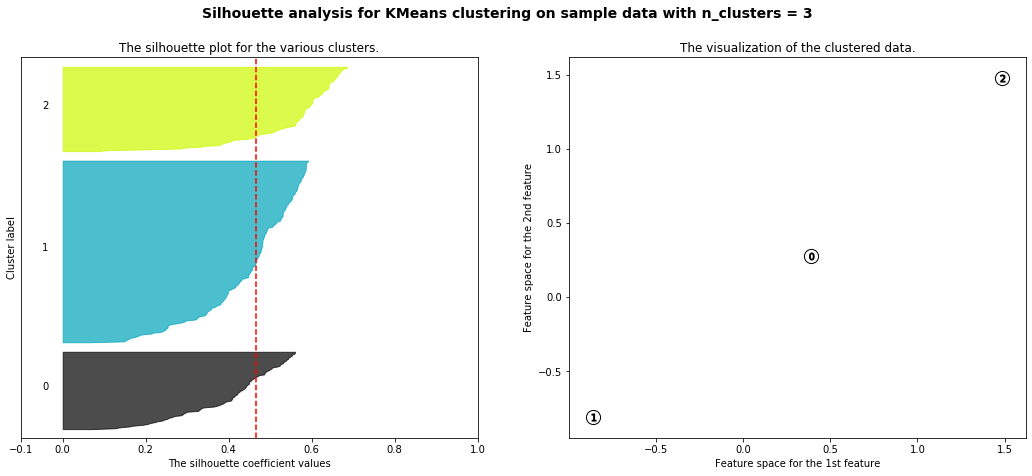

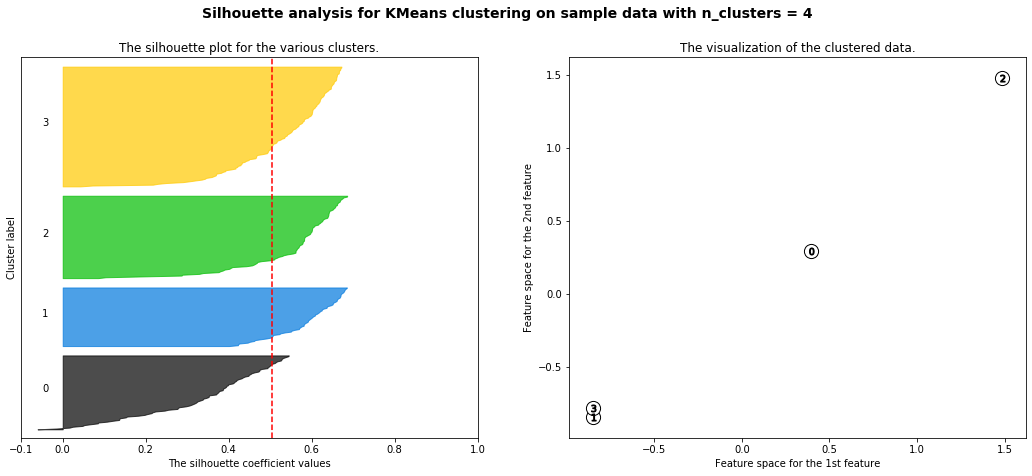

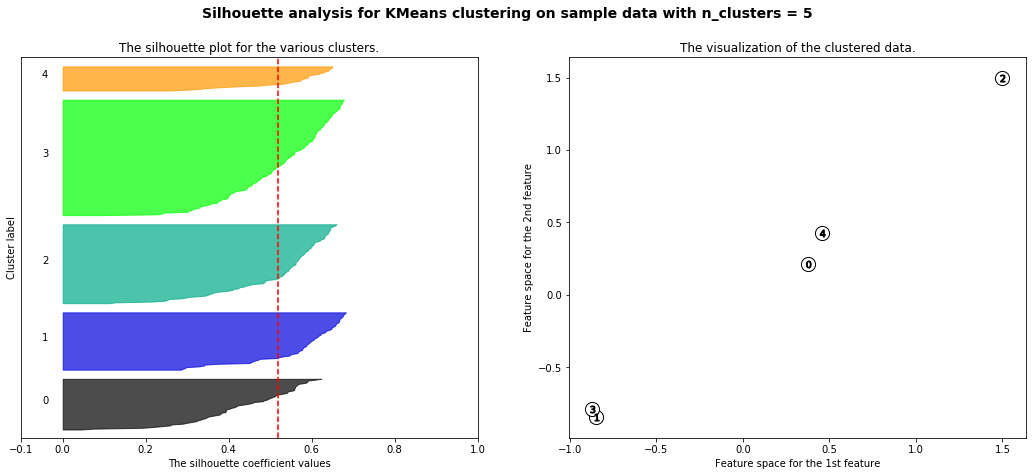

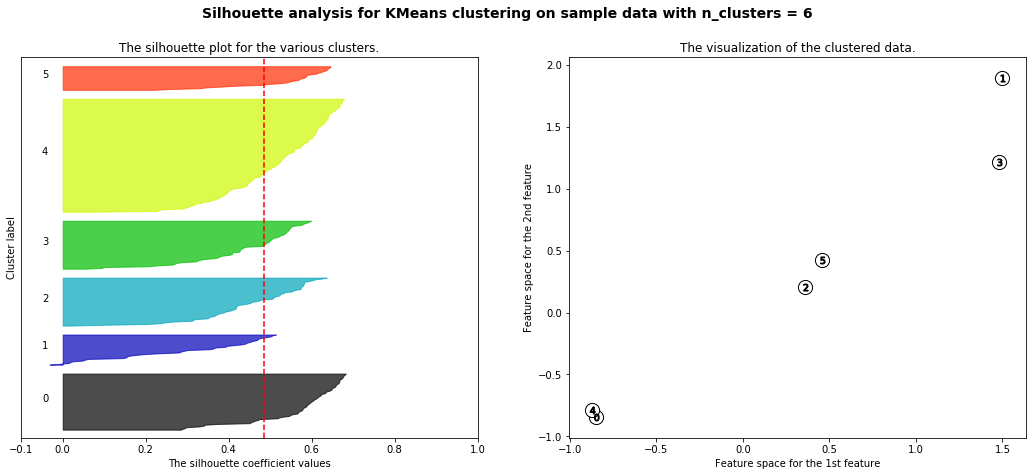

In [141]:
import matplotlib.cm as cm
range_n_clusters = [2, 3, 4, 5, 6]

for n_clusters in range_n_clusters:
    # Create a subplot with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    # The 1st subplot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax1.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(df_final_z) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value and a random generator
    # seed of 10 for reproducibility.
    clusterer = KMeans(n_clusters=n_clusters, random_state=1)
    cluster_labels = clusterer.fit_predict(df_final_z)

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(df_final_z, cluster_labels)
    print("For n_clusters =", n_clusters,
          "The average silhouette_score is :", silhouette_avg)

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(df_final_z, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = \
            sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 2nd Plot showing the actual clusters formed
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
#    ax2.scatter(df_final_z[:, 1], df_final_z[:, 5], marker='.', s=30, lw=0, alpha=0.7, c=colors, edgecolor='k')

    # Labeling the clusters
    centers = clusterer.cluster_centers_
    # Draw white circles at cluster centers
    ax2.scatter(centers[:, 0], centers[:, 1], marker='o', c="white", alpha=1, s=200, edgecolor='k')

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker='$%d$' % i, alpha=1, s=50, edgecolor='k')

        ax2.set_title("The visualization of the clustered data.")
        ax2.set_xlabel("Feature space for the 1st feature")
        ax2.set_ylabel("Feature space for the 2nd feature")

        plt.suptitle(("Silhouette analysis for KMeans clustering on sample data with n_clusters = %d" % n_clusters), fontsize=14, fontweight='bold')

In [92]:
#Using the KMeans cluster object to assign cluster_id to each record in X.
centroid_df = pd.DataFrame(centroids, columns = list(df_final_z) )

prediction=cluster.predict(df_final_z)

# Store the cluster id into a new "group" column
df_final["GROUP"] = prediction     # Creating a new column "GROUP" which will hold the cluster id of each record

df_final.groupby(["GROUP"]).count()

,mpg,cyl,disp,hp,wt,acc,yr,origin,Hierarchial_labels
GROUP,,,,,,,,,
0,90,90,90,90,90,90,90,90,90
1,210,210,210,210,210,210,210,210,210
2,98,98,98,98,98,98,98,98,98


In [75]:
for i in cluster_range:
    points = np.array(df_final.loc[df_final['GROUP'] == i])
    
points

array([], shape=(0, 9), dtype=float64)

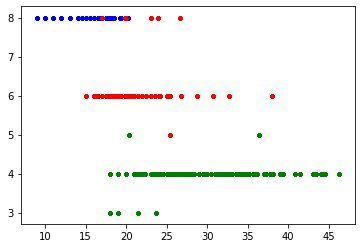

In [76]:
colors = ['r', 'g', 'b', 'y', 'c', 'm']
fig, ax = plt.subplots()
c = np.array([3,3])

for i in labels:
        points = np.array(df_final.loc[df_final['GROUP'] == i])
        #c[i] = np.mean(points, axis=0)
        ax.scatter(points[:, 0], points[:, 1], s=7, c=colors[i])

###### By visualizing the above plots for no.of cluster 3 and 4 - The no.of.cluster with 4 groups has overlaps and outliers and hence it is not recommended. Hence building a model based on 3 clusters will be more efficient.

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x000002206427BE48>,
      dtype=object)

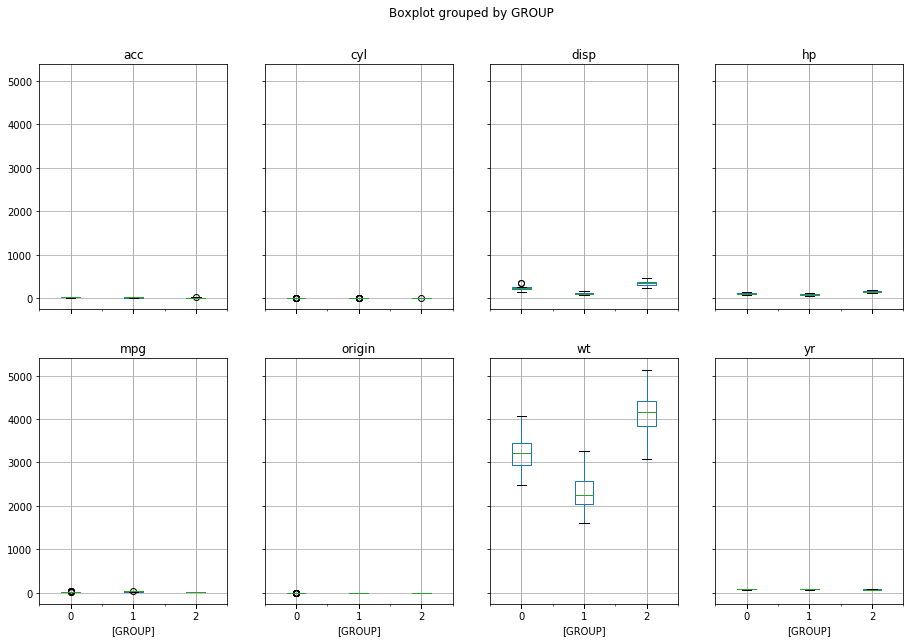

In [77]:
#Visualize the groups created using K Means
df_final.boxplot(by = 'GROUP',  layout=(2,4), figsize=(15, 10))

Handle the outliers in the group created to have a better model.

In [78]:
def replace(group):
    median, std = group.median(), group.std()  #Get the median and the standard deviation of every group 
    outliers = (group - median).abs() > 2.5*std # Subtract median from every member of each group. Take absolute values > 2std
    group[outliers] = group.median() # replacing group outliers with group median      
    return group

data_corrected = (df_final.groupby('GROUP').transform(replace)) 
df_KMeans_cluster3 = data_corrected.join(pd.DataFrame(df_final['GROUP']))

In [79]:
df_KMeans_cluster3.head(5)

,mpg,cyl,disp,hp,wt,acc,yr,origin,GROUP
0,18.0000000,8,307.0000000,130.0000000,3504.0000000,12.0000000,70,1,2
1,15.0000000,8,350.0000000,165.0000000,3693.0000000,11.5000000,70,1,2
2,18.0000000,8,318.0000000,150.0000000,3436.0000000,11.0000000,70,1,2
3,16.0000000,8,304.0000000,150.0000000,3433.0000000,12.0000000,70,1,2
4,17.0000000,8,302.0000000,140.0000000,3449.0000000,10.5000000,70,1,2


array([[<matplotlib.axes._subplots.AxesSubplot object at 0x0000022064B887C8>,
      dtype=object)

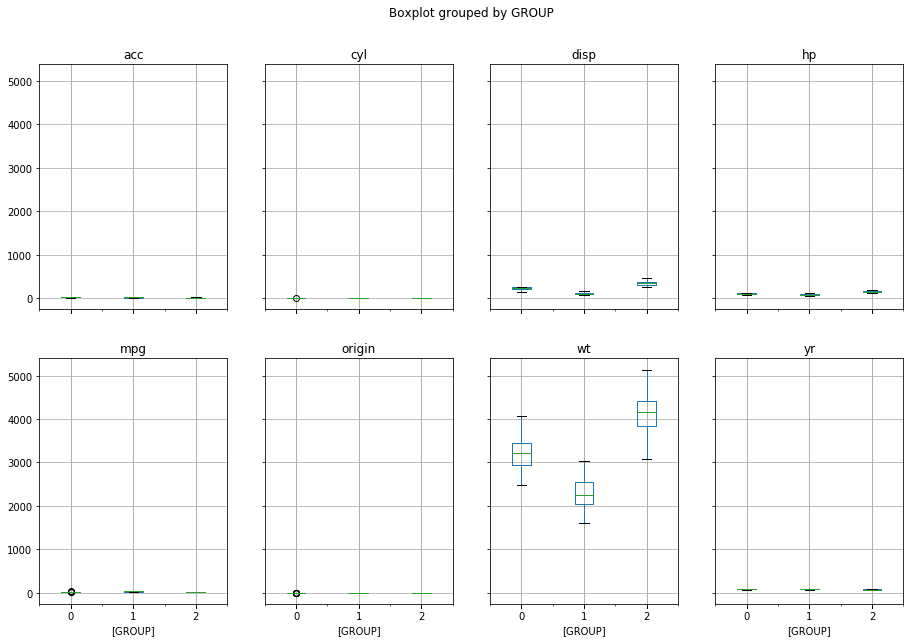

In [80]:
df_KMeans_cluster3.boxplot(by = 'GROUP', layout=(2,4), figsize=(15, 10))

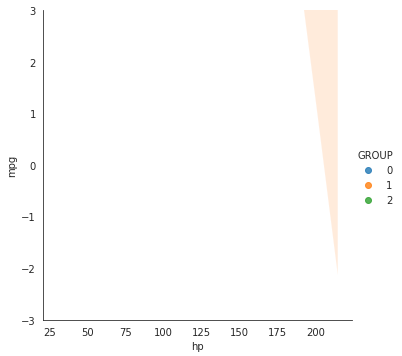

In [81]:
# mpg Vs hp

with sns.axes_style("white"):
    plot = sns.lmplot('hp','mpg',data=df_KMeans_cluster3,hue='GROUP')
plot.set(ylim = (-3,3))

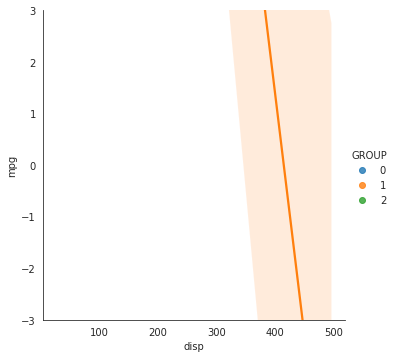

In [82]:
# mpg Vs disp

with sns.axes_style("white"):
    plot = sns.lmplot('disp','mpg',data=df_KMeans_cluster3,hue='GROUP')
plot.set(ylim = (-3,3))

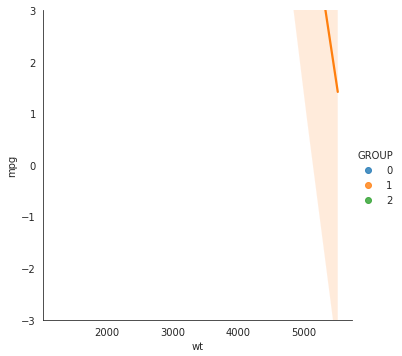

In [83]:
# mpg Vs disp

with sns.axes_style("white"):
    plot = sns.lmplot('wt','mpg',data=df_KMeans_cluster3,hue='GROUP')
plot.set(ylim = (-3,3))

###### Hierarchial Clustering - approach 2

In [84]:
from sklearn.cluster import AgglomerativeClustering 

In [85]:
from scipy.cluster.hierarchy import cophenet, dendrogram, linkage
from scipy.spatial.distance import pdist  #Pairwise distribution between data points

In [86]:
model = AgglomerativeClustering(n_clusters=3, affinity='euclidean',  linkage='complete')
model.fit(df_final_z)

#df_final['Hierarchial_labels'] = model.labels_
df_hier=df_final

df_hier.drop(['GROUP'], axis=1, inplace=True)

df_hier['Hierarchial_labels'] = model.labels_
#df_final.groupby(["Hierarchial_labels"]).count()

In [87]:
# cophenet index is a measure of the correlation between the distance of points in feature space and distance on dendrogram
# closer it is to 1, the better is the clustering

Z = linkage(df_final_z, 'complete' )
c, coph_dists = cophenet(Z , pdist(df_final_z))

c

0.8471394275927733

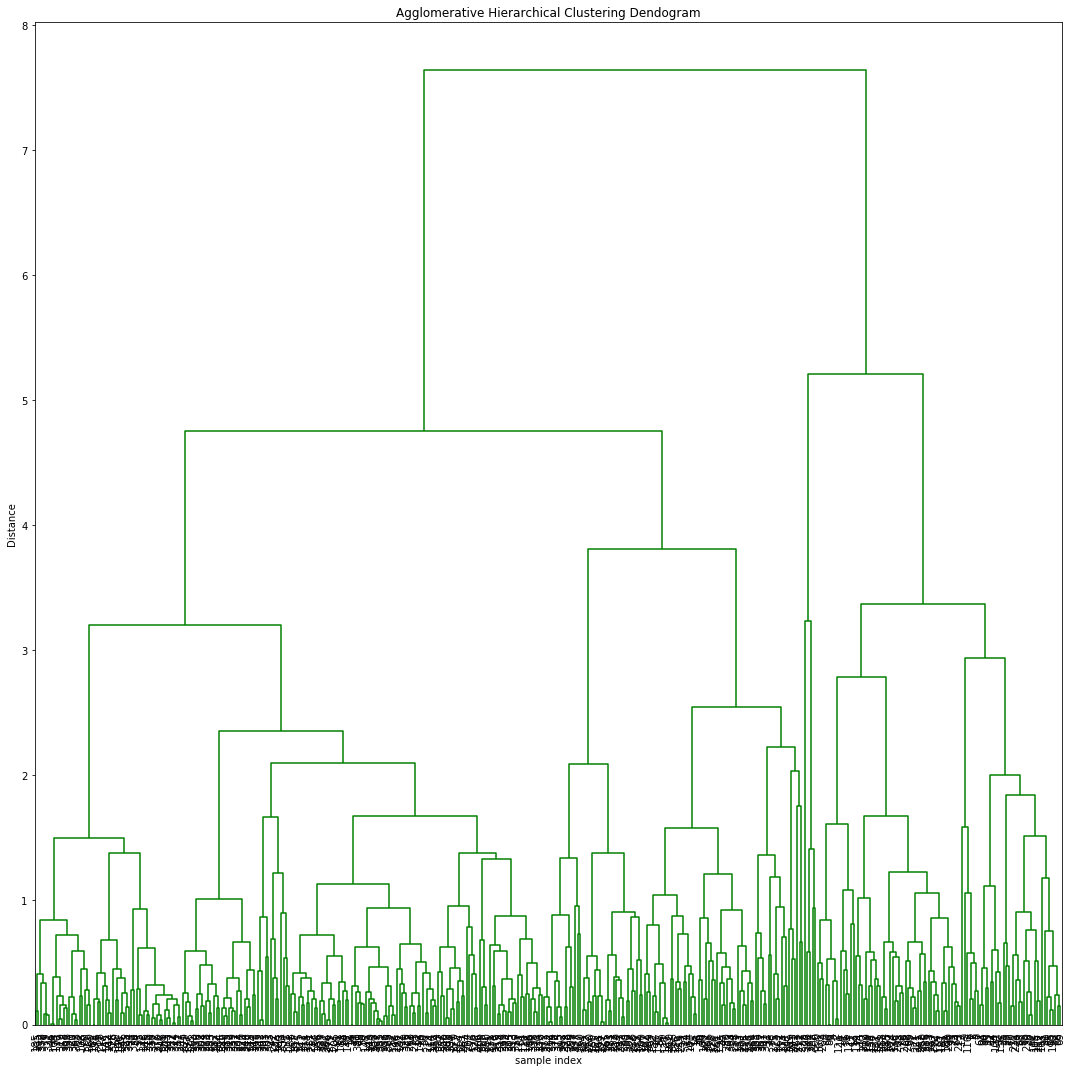

In [88]:
plt.figure(figsize=(15, 15))
plt.title('Agglomerative Hierarchical Clustering Dendogram')
plt.xlabel('sample index')
plt.ylabel('Distance')
dendrogram(Z, leaf_rotation=90.,color_threshold=2000,  leaf_font_size=10. )
plt.tight_layout()

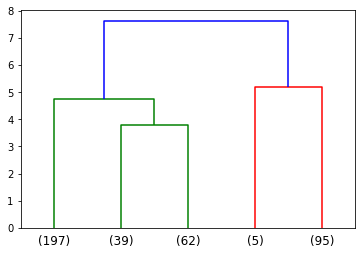

In [89]:
dendrogram(
    Z,
    truncate_mode='lastp',  # show only the last p merged clusters
    p=5,  # show only the last p merged clusters
)
plt.show()

###### Share your insights about the difference in using these two methods.

###### Question #5: Answer below questions based on outcomes of using ML based methods

#### Mention how many optimal clusters are present in the data and what could be the possible reason behind it.

#### Use linear regression model on different clusters separately and print the coefficients of the models individually

In [90]:
#Look at diff groups in Kmeans clusters
df_KMeans_cluster3['GROUP'].value_counts()

1    210
2     98
0     90
Name: GROUP, dtype: int64

In [93]:
#create a dataframe for each KMeans cluster to build a linear regression model.

#df_Kcluster0= df_KMeans_cluster3[df_KMeans_cluster3.GROUP == 0]
#df_Kcluster1= df_KMeans_cluster3[df_KMeans_cluster3.GROUP == 1]
#df_Kcluster2= df_KMeans_cluster3[df_KMeans_cluster3.GROUP == 2]

df_Kcluster0 = df_final[df_final.GROUP == 0]
df_Kcluster1 = df_final[df_final.GROUP == 1]
df_Kcluster2 = df_final[df_final.GROUP == 2]
#df_Kcluster0

In [94]:
#Data split on cluster 0
array_cluster0 = df_Kcluster0.values
X = array_cluster0[:, 1:5] # select all rows and first 4 columns which are the attributes
y = array_cluster0[:,0]   # select all rows and the 0th column which is the target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=41)

In [95]:
#Pre-processing
sc=StandardScaler()
scaledX_train = sc.fit_transform(X_train)
scaledX_test = sc.transform(X_test)

In [96]:
#Build Linear Regression model on cluster 0
from sklearn.linear_model import LinearRegression
LR_kmeans_c0 = LinearRegression()

LR_kmeans_c0.fit(X_train, y_train)

print("Training data accuracy:", LR_kmeans_c0.score(X_train, y_train))
print("Testing data accuracy:", LR_kmeans_c0.score(X_test, y_test))

Training data accuracy: 0.16222459805899694
Testing data accuracy: 0.11517510791026875


In [97]:
print("Coefficients of LR model with 3 KMeans clusters - cluster 0:",LR_kmeans_c0.coef_)

Coefficients of LR model with 3 KMeans clusters - cluster 0: [ 1.7431336  -0.01446438 -0.0412055  -0.00334445]


In [98]:
print("Intercept of LR model with 3 KMeans clusters - cluster 0:", LR_kmeans_c0.intercept_)

Intercept of LR model with 3 KMeans clusters - cluster 0: 27.350498392412963


In [99]:
#Data split on cluster 1
array_cluster1 = df_Kcluster1.values
X = array_cluster1[:,1:5] # select all rows and first 4 columns which are the attributes
y = array_cluster1[:,0]   # select all rows and the 0th column which is the target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1)

In [100]:
#Build Linear Regression model on cluster 1
LR_kmeans_c1 = LinearRegression()

LR_kmeans_c1.fit(X_train, y_train)

print("Training data accuracy:", LR_kmeans_c1.score(X_train, y_train))
print("Testing data accuracy:", LR_kmeans_c1.score(X_test, y_test))

Training data accuracy: 0.3826819704936135
Testing data accuracy: 0.41532693379574714


In [101]:
print("Coefficients of LR model with 3 KMeans clusters - cluster 1:",LR_kmeans_c1.coef_)

Coefficients of LR model with 3 KMeans clusters - cluster 1: [ 1.76970109  0.0047314  -0.1498727  -0.00487657]


In [102]:
#Data split on cluster 2
array_cluster2 = df_Kcluster2.values
X = array_cluster2[:,1:5] # select all rows and first 4 columns which are the attributes
y = array_cluster2[:,0]   # select all rows and the 0th column which is the target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=30)

In [103]:
#Build Linear Regression model on cluster 2
LR_kmeans_c2 = LinearRegression()

LR_kmeans_c2.fit(X_train, y_train)

print("Training data accuracy:", LR_kmeans_c2.score(X_train, y_train))
print("Testing data accuracy:", LR_kmeans_c2.score(X_test, y_test))

Training data accuracy: 0.3321280389041159
Testing data accuracy: 0.342246527123681


In [104]:
print("Coefficients of LR model with all 3 KMeans clusters - cluster 2:",LR_kmeans_c2.coef_)

Coefficients of LR model with all 3 KMeans clusters - cluster 2: [ 0.          0.01198618 -0.04906216 -0.00175563]


In [105]:
#Build linear model based on all 3 KMeans clusters 
#array=df_KMeans_cluster3
array=df_final
X = array.drop(['mpg', 'GROUP'], axis=1) # select all rows and first 4 columns which are the attributes
y = array[['mpg']]  # select all rows and the 0th column which is the target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1)

In [106]:
#Build linear model based on all 3 KMeans clusters 
LR_kmeans_cluster = LinearRegression()

LR_kmeans_cluster.fit(X_train, y_train)

print("Training data accuracy:", LR_kmeans_cluster.score(X_train, y_train))
print("Testing data accuracy:", LR_kmeans_cluster.score(X_test, y_test))

Training data accuracy: 0.8267936288604669
Testing data accuracy: 0.8436657440333685


In [107]:
print("Coefficients of LR model with all 3 KMeans clusters:",LR_kmeans_cluster.coef_)

Coefficients of LR model with all 3 KMeans clusters: [[-1.14172755  0.01916775 -0.06162    -0.00592103 -0.08771176  0.76622897
   1.04177507  4.48827077]]


In [108]:
#create a dataframe for each Hierarchial cluster to build a linear regression model.

df_Hiercluster0= df_hier[df_hier.Hierarchial_labels == 0]
df_Hiercluster1= df_hier[df_hier.Hierarchial_labels == 1]
df_Hiercluster2= df_hier[df_hier.Hierarchial_labels == 2]


In [109]:
#Data split on cluster 0
hier_cluster0 = df_Hiercluster0.values
X = hier_cluster0[:,1:5] # select all rows and first 4 columns which are the attributes
y = hier_cluster0[:,0]   # select all rows and the 0th column which is the target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1)

In [110]:
#Build Linear Regression model on cluster 0
LR_Hier_c0 = LinearRegression()

LR_Hier_c0.fit(X_train, y_train)

print("Training data accuracy:", LR_Hier_c0.score(X_train, y_train))
print("Testing data accuracy:", LR_Hier_c0.score(X_test, y_test))

Training data accuracy: 0.5724531043686767
Testing data accuracy: 0.5980397020524748


In [111]:
print("Coefficients of LR model with 3 Hierarchial clusters - cluster 0:",LR_Hier_c0.coef_)

Coefficients of LR model with 3 Hierarchial clusters - cluster 0: [ 0.98558918 -0.04528857 -0.12608944 -0.0030878 ]


In [112]:
#Data split on cluster 1
hier_cluster1 = df_Hiercluster1.values
X = hier_cluster1[:,1:5] # select all rows and first 4 columns which are the attributes
y = hier_cluster1[:,0]   # select all rows and the 0th column which is the target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=11)

In [113]:
#Build Linear Regression model on cluster 1
LR_Hier_c1 = LinearRegression()

LR_Hier_c1.fit(X_train, y_train)

print("Training data accuracy:", LR_Hier_c1.score(X_train, y_train))
print("Testing data accuracy:", LR_Hier_c1.score(X_test, y_test))

Training data accuracy: 0.2947705998717244
Testing data accuracy: 0.3578202543361044


In [114]:
print("Coefficients of LR model with 3 Hierarchial clusters - cluster 1:",LR_Hier_c1.coef_)

Coefficients of LR model with 3 Hierarchial clusters - cluster 1: [ 0.          0.01025655 -0.0431917  -0.00175458]


In [115]:
#Data split on cluster 2
hier_cluster2 = df_Hiercluster2.values
X = hier_cluster2[:,1:5] # select all rows and first 4 columns which are the attributes
y = hier_cluster2[:,0]   # select all rows and the 0th column which is the target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [116]:
#Build Linear Regression model on cluster 1
LR_Hier_c2 = LinearRegression()

LR_Hier_c2.fit(X_train, y_train)

print("Training data accuracy:", LR_Hier_c2.score(X_train, y_train))
print("Testing data accuracy:", LR_Hier_c2.score(X_test, y_test))

Training data accuracy: 1.0
Testing data accuracy: 0.9123506884129624


In [117]:
print("Coefficients of LR model with 3 Hierarchial clusters - cluster 2:",LR_Hier_c2.coef_)

Coefficients of LR model with 3 Hierarchial clusters - cluster 2: [-2.77555756e-17  6.14650605e-02 -3.28060628e-03 -1.31604880e-02]


In [118]:
#Build Linear Regression model on all 3 Hierarchial clusters
LR_Hier_cluster = LinearRegression()

LR_Hier_cluster.fit(X_train, y_train)

print("Training data accuracy:", LR_Hier_cluster.score(X_train, y_train))
print("Testing data accuracy:", LR_Hier_cluster.score(X_test, y_test))

Training data accuracy: 1.0
Testing data accuracy: 0.9123506884129624


In [119]:
print("Coefficients of LR model with 3 Hierarchial clusters:",LR_Hier_cluster.coef_)

Coefficients of LR model with 3 Hierarchial clusters: [-2.77555756e-17  6.14650605e-02 -3.28060628e-03 -1.31604880e-02]


#### How using different models for different clusters will be helpful in this case and how it will be different than using one single model without clustering? Mention how it impacts performance and prediction.

###### Question #6: Improvisation:

#### Detailed suggestions or improvements or on quality, quantity, variety, velocity, veracity etc. on the data points collected by the company to perform a better data analysis in future.

# PART TWO - DOMAIN : Manufacturing

###### Design a synthetic data generation model which can impute values [Attribute: Quality] wherever empty the company has missed recording the data.

In [120]:
df_manuf=pd.read_excel('C:\AIML\Assessment\R4-UnSupervised\External\Company.xlsx')

In [121]:
df_manuf.head(10)

,A,B,C,D,Quality
0,47,27,45,108,Quality A
1,174,133,134,166,Quality B
2,159,163,135,131,NaN
3,61,23,3,44,Quality A
4,59,60,9,68,Quality A
5,153,140,154,199,NaN
6,34,28,78,22,Quality A
7,191,144,143,154,NaN
8,160,181,194,178,Quality B
9,145,178,158,141,NaN


In [122]:
df_manuf.isnull().sum()

A           0
B           0
C           0
D           0
Quality    18
dtype: int64

In [123]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer
from sklearn.ensemble import RandomForestClassifier

# print total missing
print('Missing: \n', df_manuf.isnull().sum())

imputer = SimpleImputer(strategy="most_frequent")
imputed_df=imputer.fit_transform(df_manuf)
imputed_df=pd.DataFrame(imputed_df, columns=df_manuf.columns)
print('\nAfter imputing- Missing: \n', imputed_df.isnull().sum())



Missing: 
 A           0
B           0
C           0
D           0
Quality    18
dtype: int64

After imputing- Missing: 
 A          0
B          0
C          0
D          0
Quality    0
dtype: int64


In [124]:
X=imputed_df.drop('Quality', axis=1)
y=imputed_df['Quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20,random_state=20)

sc=StandardScaler()
scaledxtrain = sc.fit_transform(X_train)
scaledxtest = sc.transform(X_test)


rf=RandomForestClassifier(n_estimators=12,max_depth=4)
rf.fit(scaledxtrain,y_train)

print("What is the Testing Accuracy")
print(rf.score(scaledxtest,y_test))

print("What is the Training Accuracy")
print(rf.score(scaledxtrain,y_train))


What is the Testing Accuracy
0.9230769230769231
What is the Training Accuracy
0.9375


#### Detailed suggestions or improvements or on collected data and synthetic data’s quality, quantity, variety, velocity,veracity etc. in order to perform a better data analysis in future.